In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

%matplotlib inline

In [15]:
df = pd.read_csv('Integrated Data Part 1.csv')
df =df[
    (df['category'] != 'Unknown') &
    (df['url'] != 'No URL')
]


In [16]:
df

,url,title,category,duration_seconds,view_count,like_count,comment_count
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55,1097261,165069,45568
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52,95273478,1468403,6862
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23,479077,9712,92
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31,198509,7118,24
4,https://www.youtube.com/watch?v=zeKkx4NsvCg,Og And Saaho Idharu Brothers Ani Telusundhi | ...,cinema content,24,27017,940,2
...,...,...,...,...,...,...,...
1720,https://www.youtube.com/watch?v=-3bG5bzUKmI,Instant Crispy Potato Triangles Recipe | Party...,food recipes,21,13172670,195142,485
1721,https://www.youtube.com/watch?v=-3Tc6b74TXE,Singapore ki jeans😂 #shorts #funny #comedy,funny content,60,6596645,192107,152
1722,https://www.youtube.com/watch?v=-30pyWb7mxs,The male need and urge for FREE #warframe #gam...,gaming,60,150360,9998,192
1723,https://www.youtube.com/watch?v=-2KIoyDX8Dc,Steal our UDAIPUR Travel Guide ✨💕 #udaipur #tr...,travelling,59,1538968,52389,174


In [17]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 url                 0
title               0
category            0
duration_seconds    0
view_count          0
like_count          0
comment_count       0
dtype: int64


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1725 entries, 0 to 1724
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               1725 non-null   object
 1   title             1725 non-null   object
 2   category          1725 non-null   object
 3   duration_seconds  1725 non-null   int64 
 4   view_count        1725 non-null   int64 
 5   like_count        1725 non-null   int64 
 6   comment_count     1725 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 107.8+ KB
None


In [19]:
print(df.describe())

       duration_seconds    view_count    like_count  comment_count
count        1725.00000  1.725000e+03  1.725000e+03    1725.000000
mean          988.37913  1.415733e+07  2.799922e+05    2787.226667
std          4129.29105  4.787109e+07  9.603778e+05   14061.793430
min             0.00000  1.000000e+00  0.000000e+00       0.000000
25%            20.00000  2.282820e+05  5.414000e+03      89.000000
50%            50.00000  1.619066e+06  3.237300e+04     408.000000
75%           373.00000  9.232643e+06  1.929470e+05    1635.000000
max         57468.00000  1.225592e+09  1.979052e+07  440712.000000


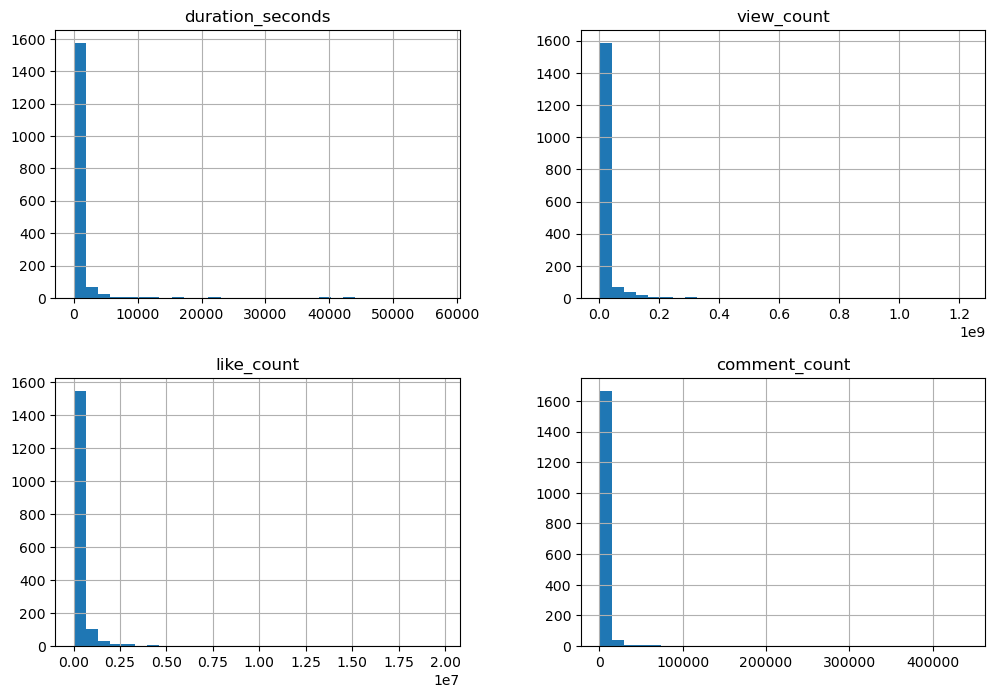

In [20]:
numeric_cols = ['duration_seconds','view_count','like_count','comment_count']

# Histograms
df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.show()

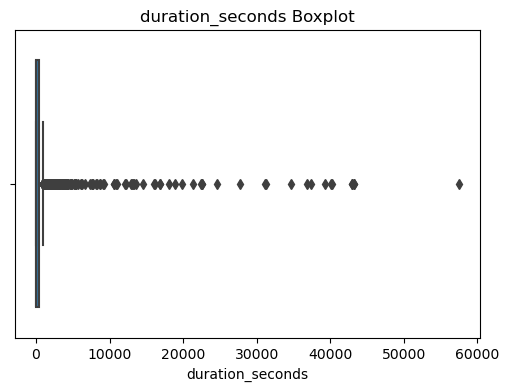

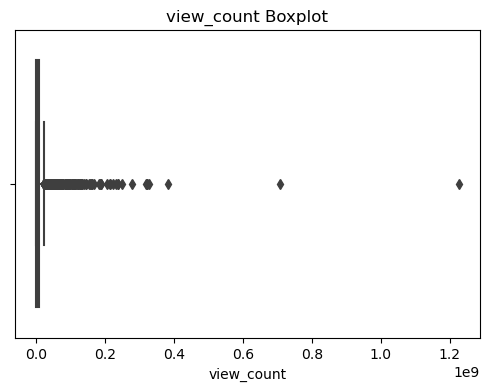

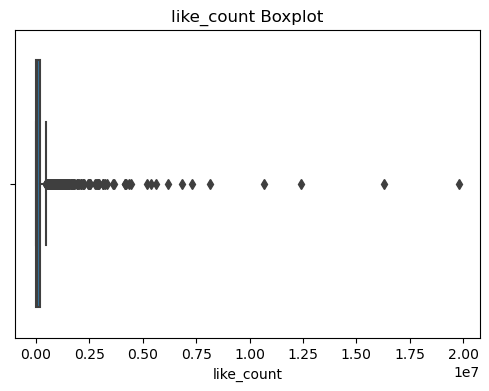

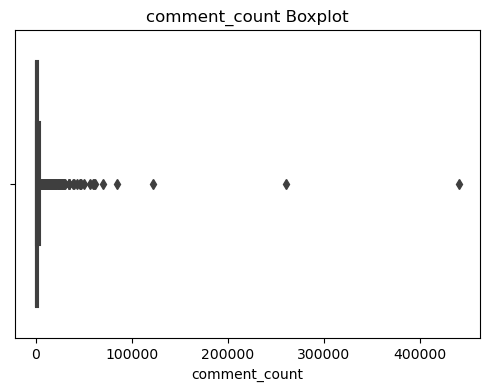

In [21]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

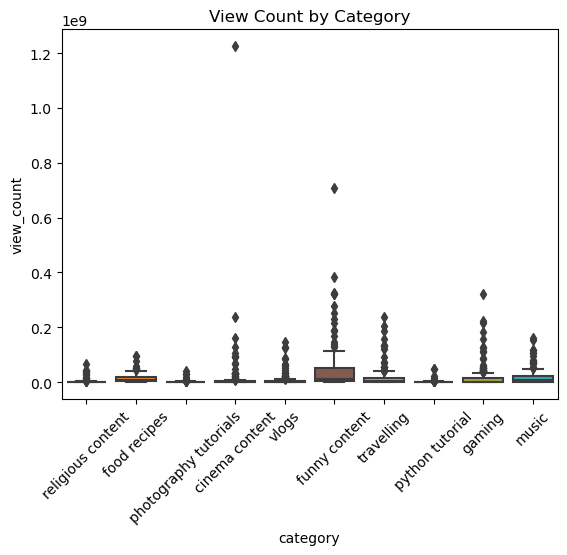

In [22]:
sns.boxplot(x='category', y='view_count', data=df)
plt.xticks(rotation=45)
plt.title('View Count by Category')
plt.show()

In [23]:
print("\nCorrelation:\n", df[numeric_cols].corr())
print("\nCovariance:\n", df[numeric_cols].cov())


Correlation:
                   duration_seconds  view_count  like_count  comment_count
duration_seconds          1.000000   -0.049369   -0.045712       0.045632
view_count               -0.049369    1.000000    0.870416       0.137508
like_count               -0.045712    0.870416    1.000000       0.189500
comment_count             0.045632    0.137508    0.189500       1.000000

Covariance:
                   duration_seconds    view_count    like_count  comment_count
duration_seconds      1.705104e+07 -9.758978e+09 -1.812774e+08   2.649632e+06
view_count           -9.758978e+09  2.291641e+15  4.001679e+13   9.256406e+10
like_count           -1.812774e+08  4.001679e+13  9.223256e+11   2.559127e+09
comment_count         2.649632e+06  9.256406e+10  2.559127e+09   1.977340e+08


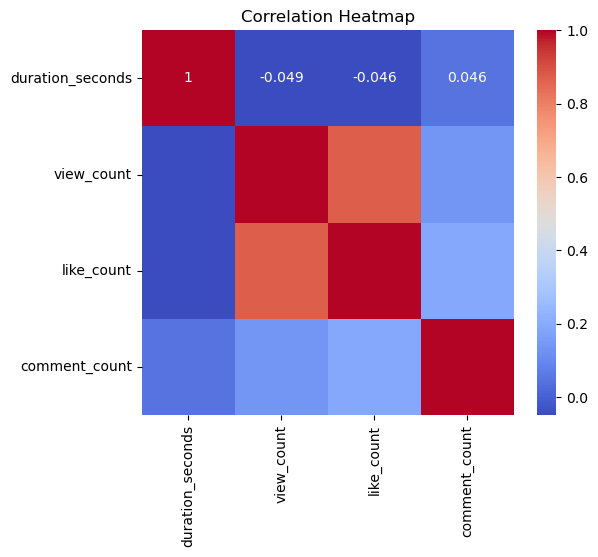

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
category_counts = df['category'].value_counts()
print("\nCategory counts:\n", category_counts)



Category counts:
 category
gaming                   195
travelling               189
photography tutorials    187
vlogs                    183
funny content            180
python tutorial          178
cinema content           169
music                    165
religious content        157
food recipes             122
Name: count, dtype: int64


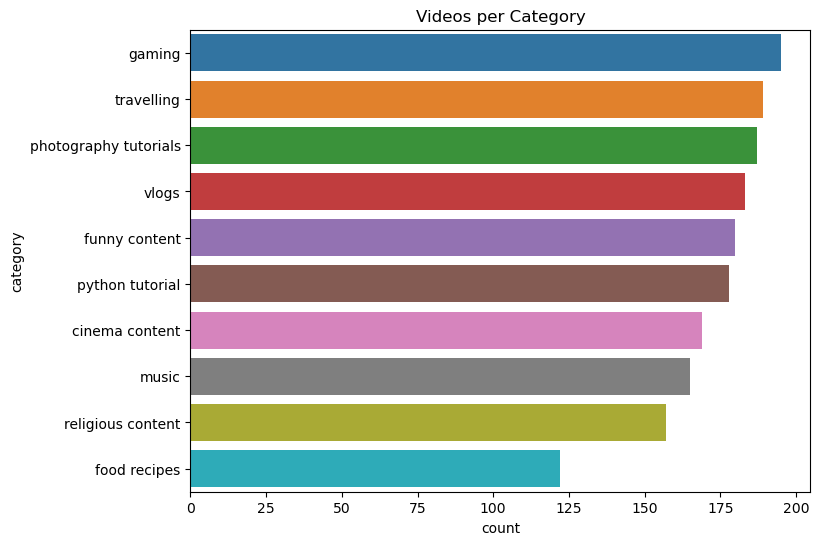

In [26]:
plt.figure(figsize=(8,6))
sns.countplot(y='category', data=df, order=category_counts.index)
plt.title('Videos per Category')
plt.show()

In [27]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]


In [28]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))


duration_seconds outliers: 295
view_count outliers: 237
like_count outliers: 228
comment_count outliers: 239


In [29]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)


In [30]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))

duration_seconds outliers: 0
view_count outliers: 0
like_count outliers: 0
comment_count outliers: 0


In [31]:
# Engagement rate feature
df['engagement'] = (
    df['like_count'] + df['comment_count']
) / df['view_count']


In [32]:
df

,url,title,category,duration_seconds,view_count,like_count,comment_count,engagement
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55.0,1097261.0,165069.0,3954,0.154041
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52.0,22739184.5,474246.5,3954,0.021030
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23.0,479077.0,9712.0,92,0.020464
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31.0,198509.0,7118.0,24,0.035978
4,https://www.youtube.com/watch?v=zeKkx4NsvCg,Og And Saaho Idharu Brothers Ani Telusundhi | ...,cinema content,24.0,27017.0,940.0,2,0.034867
...,...,...,...,...,...,...,...,...
1720,https://www.youtube.com/watch?v=-3bG5bzUKmI,Instant Crispy Potato Triangles Recipe | Party...,food recipes,21.0,13172670.0,195142.0,485,0.014851
1721,https://www.youtube.com/watch?v=-3Tc6b74TXE,Singapore ki jeans😂 #shorts #funny #comedy,funny content,60.0,6596645.0,192107.0,152,0.029145
1722,https://www.youtube.com/watch?v=-30pyWb7mxs,The male need and urge for FREE #warframe #gam...,gaming,60.0,150360.0,9998.0,192,0.067771
1723,https://www.youtube.com/watch?v=-2KIoyDX8Dc,Steal our UDAIPUR Travel Guide ✨💕 #udaipur #tr...,travelling,59.0,1538968.0,52389.0,174,0.034155


In [33]:
# Save to CSV
df.to_csv('Integrated Data.csv', index=False)


print("Integrated dataset saved to 'Integrated Data Final.csv'")

Integrated dataset saved to 'Integrated Data Final.csv'
